Prediction of Parkinson’s Disease Motor Severity

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

Load the Dataset and the first five rows are displayed to understand the structure of the dataset.

In [ ]:
df = pd.read_csv("../data/parkinsons_updrs.csv")
df.head()

,subject#,age,sex,test_time,motor_UPDRS,total_UPDRS,Jitter(%),Jitter(Abs),Jitter:RAP,Jitter:PPQ5,...,Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA,NHR,HNR,RPDE,DFA,PPE
0,1,72,0,5.6431,28.199,34.398,0.00662,0.000034,0.00401,0.00317,...,0.230,0.01438,0.01309,0.01662,0.04314,0.014290,21.640,0.41888,0.54842,0.16006
1,1,72,0,12.6660,28.447,34.894,0.00300,0.000017,0.00132,0.00150,...,0.179,0.00994,0.01072,0.01689,0.02982,0.011112,27.183,0.43493,0.56477,0.10810
2,1,72,0,19.6810,28.695,35.389,0.00481,0.000025,0.00205,0.00208,...,0.181,0.00734,0.00844,0.01458,0.02202,0.020220,23.047,0.46222,0.54405,0.21014
3,1,72,0,25.6470,28.905,35.810,0.00528,0.000027,0.00191,0.00264,...,0.327,0.01106,0.01265,0.01963,0.03317,0.027837,24.445,0.48730,0.57794,0.33277
4,1,72,0,33.6420,29.187,36.375,0.00335,0.000020,0.00093,0.00130,...,0.176,0.00679,0.00929,0.01819,0.02036,0.011625,26.126,0.47188,0.56122,0.19361


 Check Dataset Size

The shape of the dataset tells us the total number of observations and variables.

- Rows represent individual observations.
- Columns represent different features and target variables.

In [10]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 5875
Number of columns: 22


View Column Names

The column names are displayed to identify the available input features and possible target variables.

In [11]:
df.columns

Index(['subject#', 'age', 'sex', 'test_time', 'motor_UPDRS', 'total_UPDRS',
       'Jitter(%)', 'Jitter(Abs)', 'Jitter:RAP', 'Jitter:PPQ5', 'Jitter:DDP',
       'Shimmer', 'Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5',
       'Shimmer:APQ11', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'PPE'],
      dtype='object')

 Dataset Information

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5875 entries, 0 to 5874
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   subject#       5875 non-null   int64  
 1   age            5875 non-null   int64  
 2   sex            5875 non-null   int64  
 3   test_time      5875 non-null   float64
 4   motor_UPDRS    5875 non-null   float64
 5   total_UPDRS    5875 non-null   float64
 6   Jitter(%)      5875 non-null   float64
 7   Jitter(Abs)    5875 non-null   float64
 8   Jitter:RAP     5875 non-null   float64
 9   Jitter:PPQ5    5875 non-null   float64
 10  Jitter:DDP     5875 non-null   float64
 11  Shimmer        5875 non-null   float64
 12  Shimmer(dB)    5875 non-null   float64
 13  Shimmer:APQ3   5875 non-null   float64
 14  Shimmer:APQ5   5875 non-null   float64
 15  Shimmer:APQ11  5875 non-null   float64
 16  Shimmer:DDA    5875 non-null   float64
 17  NHR            5875 non-null   float64
 18  HNR     

Statistical Summary

In [13]:
df.describe()

,subject#,age,sex,test_time,motor_UPDRS,total_UPDRS,Jitter(%),Jitter(Abs),Jitter:RAP,Jitter:PPQ5,...,Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA,NHR,HNR,RPDE,DFA,PPE
count,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,...,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000
mean,21.494128,64.804936,0.317787,92.863722,21.296229,29.018942,0.006154,0.000044,0.002987,0.003277,...,0.310960,0.017156,0.020144,0.027481,0.051467,0.032120,21.679495,0.541473,0.653240,0.219589
std,12.372279,8.821524,0.465656,53.445602,8.129282,10.700283,0.005624,0.000036,0.003124,0.003732,...,0.230254,0.013237,0.016664,0.019986,0.039711,0.059692,4.291096,0.100986,0.070902,0.091498
min,1.000000,36.000000,0.000000,-4.262500,5.037700,7.000000,0.000830,0.000002,0.000330,0.000430,...,0.026000,0.001610,0.001940,0.002490,0.004840,0.000286,1.659000,0.151020,0.514040,0.021983
25%,10.000000,58.000000,0.000000,46.847500,15.000000,21.371000,0.003580,0.000022,0.001580,0.001820,...,0.175000,0.009280,0.010790,0.015665,0.027830,0.010955,19.406000,0.469785,0.596180,0.156340
50%,22.000000,65.000000,0.000000,91.523000,20.871000,27.576000,0.004900,0.000035,0.002250,0.002490,...,0.253000,0.013700,0.015940,0.022710,0.041110,0.018448,21.920000,0.542250,0.643600,0.205500
75%,33.000000,72.000000,1.000000,138.445000,27.596500,36.399000,0.006800,0.000053,0.003290,0.003460,...,0.365000,0.020575,0.023755,0.032715,0.061735,0.031463,24.444000,0.614045,0.711335,0.264490
max,42.000000,85.000000,1.000000,215.490000,39.511000,54.992000,0.099990,0.000446,0.057540,0.069560,...,2.107000,0.162670,0.167020,0.275460,0.488020,0.748260,37.875000,0.966080,0.865600,0.731730


Check Missing Values

In [14]:
df.isnull().sum()

subject#         0
age              0
sex              0
test_time        0
motor_UPDRS      0
total_UPDRS      0
Jitter(%)        0
Jitter(Abs)      0
Jitter:RAP       0
Jitter:PPQ5      0
Jitter:DDP       0
Shimmer          0
Shimmer(dB)      0
Shimmer:APQ3     0
Shimmer:APQ5     0
Shimmer:APQ11    0
Shimmer:DDA      0
NHR              0
HNR              0
RPDE             0
DFA              0
PPE              0
dtype: int64

Check Duplicate Rows

Duplicate observations may unnecessarily repeat the same information.

Therefore, the dataset is checked for duplicate rows.

In [15]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


Remove Duplicate Rows

Any exact duplicate observations are removed from the dataset to avoid repeated records during model training.

In [16]:
df = df.drop_duplicates()
print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (5875, 22)


Distribution of Target Variable

The target variable selected for this regression problem is "total_UPDRS".

A histogram is plotted to understand how the target values are distributed.

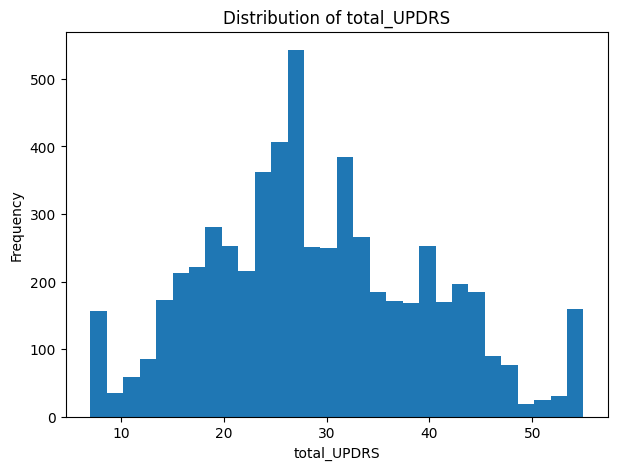

In [17]:
plt.figure(figsize=(7, 5))
plt.hist(df["total_UPDRS"], bins=30)
plt.xlabel("total_UPDRS")
plt.ylabel("Frequency")
plt.title("Distribution of total_UPDRS")
plt.show()

 Distribution of Age

The distribution of the age feature is examined to understand the age range of the patients present in the dataset.

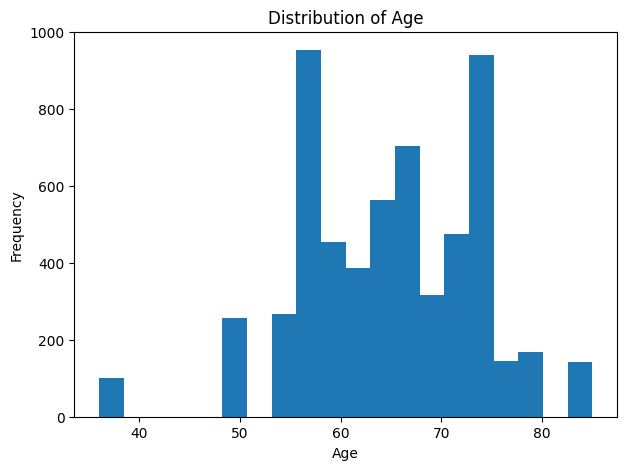

In [18]:
plt.figure(figsize=(7, 5))
plt.hist(df["age"], bins=20)
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Distribution of Age")
plt.show()

 Distribution of PPE

PPE is one of the voice-related features available in the dataset.

Its distribution is examined to understand the range and frequency of PPE values.

Voice features such as PPE can contain useful information about Parkinson's disease severity.

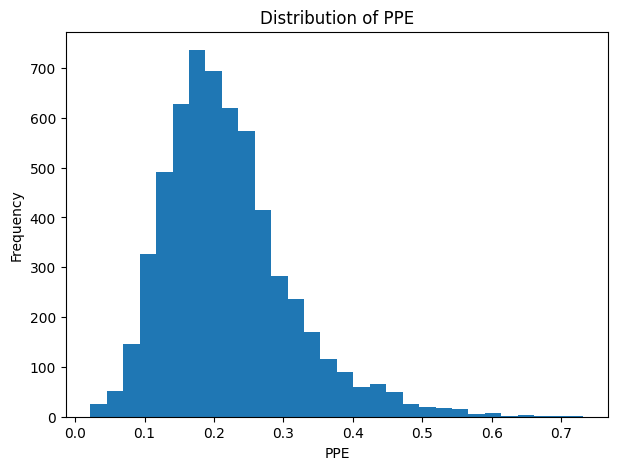

In [19]:
plt.figure(figsize=(7, 5))
plt.hist(df["PPE"], bins=30)
plt.xlabel("PPE")
plt.ylabel("Frequency")
plt.title("Distribution of PPE")
plt.show()

Correlation Heatmap

The correlation heatmap shows positive and negative relationships between the numerical variables.

Features showing stronger correlation with 'total_UPDRS' may be useful predictors for the regression models.

The heatmap also helps identify highly correlated input variables.

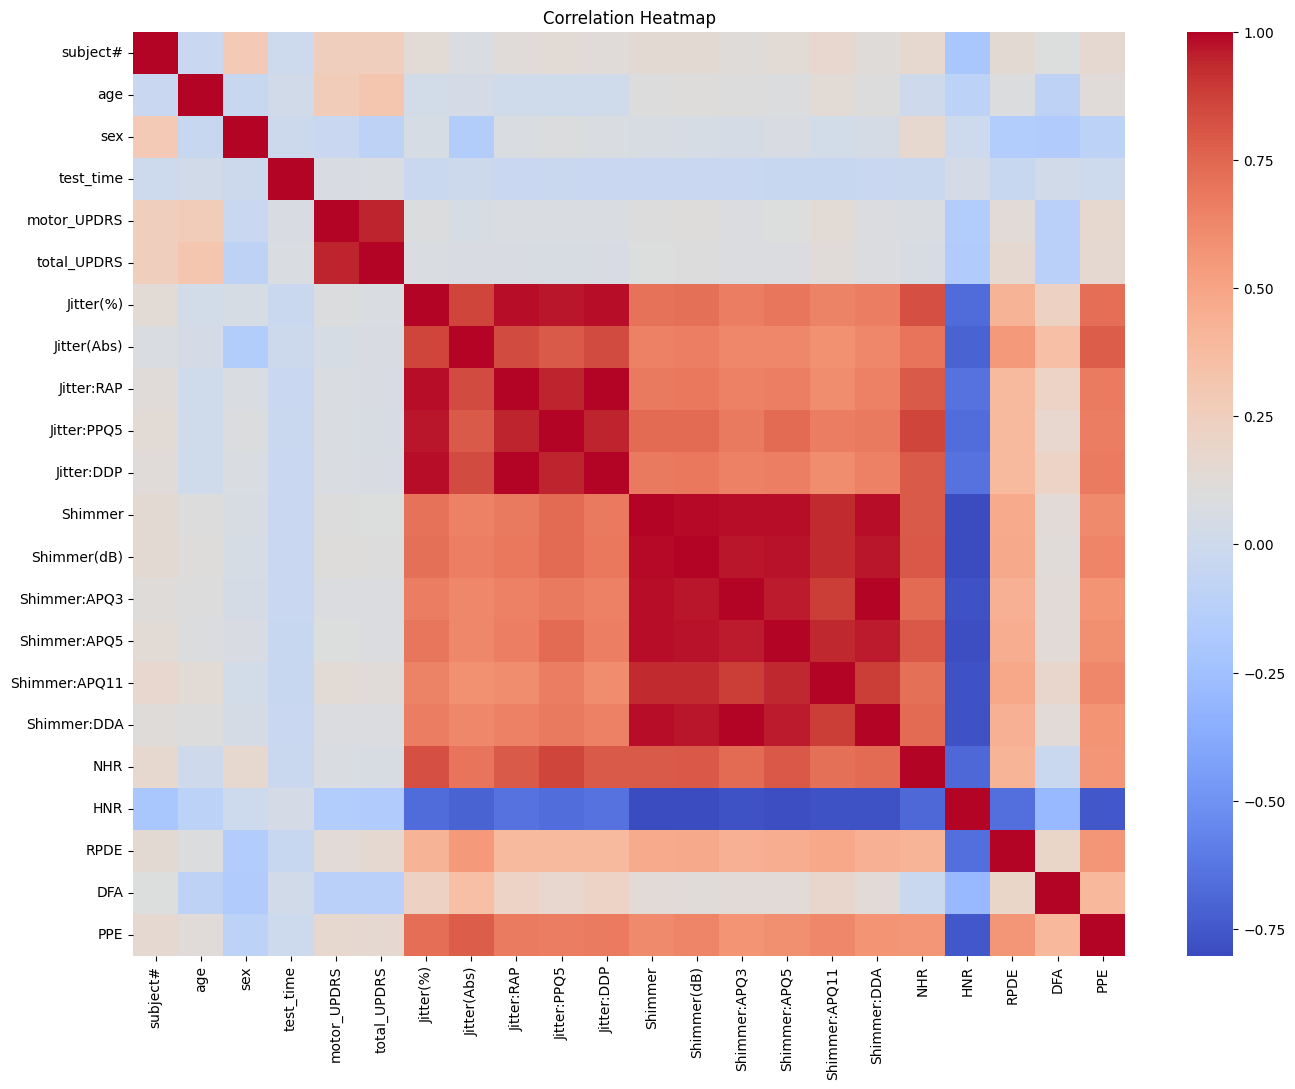

In [20]:
plt.figure(figsize=(16, 12))
correlation = df.corr()
sns.heatmap(correlation, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

Correlation of Features with total_UPDRS
The correlation values help identify which variables have stronger linear relationships with 'total_UPDRS'.

A larger positive or negative correlation indicates a stronger relationship with the target variable.

In [21]:
correlation["total_UPDRS"].sort_values(ascending=False)

total_UPDRS      1.000000
motor_UPDRS      0.947231
age              0.310290
subject#         0.253643
RPDE             0.156897
PPE              0.156195
Shimmer:APQ11    0.120838
Shimmer(dB)      0.098790
Shimmer          0.092141
Shimmer:APQ5     0.083467
Shimmer:DDA      0.079363
Shimmer:APQ3     0.079363
test_time        0.075263
Jitter(%)        0.074247
Jitter(Abs)      0.066927
Jitter:DDP       0.064027
Jitter:RAP       0.064015
Jitter:PPQ5      0.063352
NHR              0.060952
sex             -0.096559
DFA             -0.113475
HNR             -0.162117
Name: total_UPDRS, dtype: float64

Relationship Between Age and total_UPDRS

A scatter plot is used to study the relationship between the patient's age and total_UPDRS

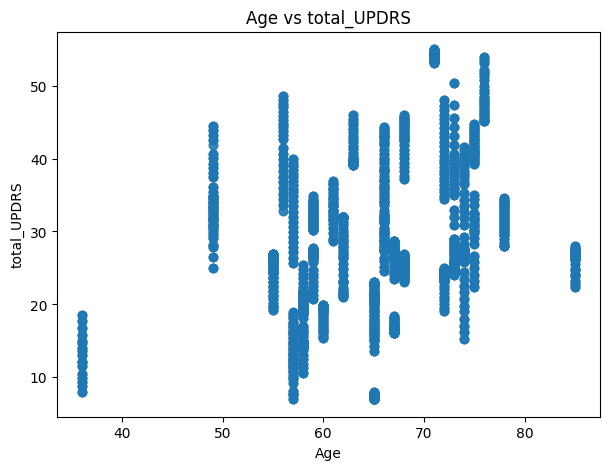

In [22]:
plt.figure(figsize=(7, 5))
plt.scatter(df["age"], df["total_UPDRS"], alpha=0.5)
plt.xlabel("Age")
plt.ylabel("total_UPDRS")
plt.title("Age vs total_UPDRS")
plt.show()

Relationship Between PPE and total_UPDRS

The scatter plot shows the relationship between PPE and 'total_UPDRS'.

The distribution of points indicates that voice measurements can provide useful information for predicting Park

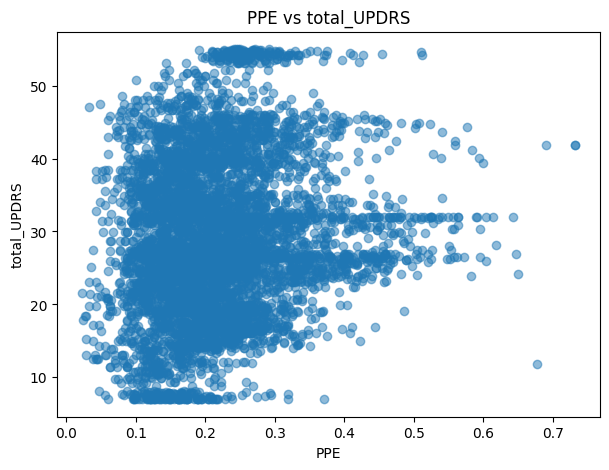

In [23]:
plt.figure(figsize=(7, 5))
plt.scatter(df["PPE"], df["total_UPDRS"], alpha=0.5)
plt.xlabel("PPE")
plt.ylabel("total_UPDRS")
plt.title("PPE vs total_UPDRS")
plt.show()

 Handle Missing Values
 

In [24]:
numeric_columns = df.select_dtypes(include=np.number).columns
df[numeric_columns] = df[numeric_columns].fillna(
    df[numeric_columns].median()
)